In [2]:
!pip install pandas matplotlib seaborn psycopg2-binary


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import pandas as pd
import psycopg2

# Connect to PostgreSQL
conn = psycopg2.connect(
    host="localhost",
    database="flight_pricing_db",
    user="postgres",
    password="password"
)

# Query the table
query = "SELECT * FROM flight_revenue_analytics;"
df = pd.read_sql_query(query, conn)

# Show first 5 rows
print(df.head())

# Close connection
conn.close()


       airline    source destination  total_stops  price  date  month  year  \
0       IndiGo  Banglore   New Delhi            0   3897    24      3  2019   
1    Air India   Kolkata    Banglore            2   7662     1      5  2019   
2  Jet Airways     Delhi      Cochin            2  13882     9      6  2019   
3       IndiGo   Kolkata    Banglore            1   6218    12      5  2019   
4       IndiGo  Banglore   New Delhi            1  13302     1      3  2019   

   dep_hours  dep_min  arrival_hours  arrival_min  duration_hours  \
0         22       20              1           10               2   
1          5       50             13           15               7   
2          9       25              4           25              19   
3         18        5             23           30               5   
4         16       50             21           35               4   

   duration_min                 route  duration_minutes departure_bucket  \
0            50  Banglore - New De

C:\Users\rihro\AppData\Local\Temp\ipykernel_9864\1661891355.py:14: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query(query, conn)


In [4]:
df.shape

(10683, 20)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10683 entries, 0 to 10682
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   airline           10683 non-null  object 
 1   source            10683 non-null  object 
 2   destination       10683 non-null  object 
 3   total_stops       10683 non-null  int64  
 4   price             10683 non-null  int64  
 5   date              10683 non-null  int64  
 6   month             10683 non-null  int64  
 7   year              10683 non-null  int64  
 8   dep_hours         10683 non-null  int64  
 9   dep_min           10683 non-null  int64  
 10  arrival_hours     10683 non-null  int64  
 11  arrival_min       10683 non-null  int64  
 12  duration_hours    10683 non-null  int64  
 13  duration_min      10683 non-null  int64  
 14  route             10683 non-null  object 
 15  duration_minutes  10683 non-null  int64  
 16  departure_bucket  10683 non-null  object

In [6]:
df.describe()

,total_stops,price,date,month,year,dep_hours,dep_min,arrival_hours,arrival_min,duration_hours,duration_min,duration_minutes,price_per_hour
count,10683.000000,10683.000000,10683.000000,10683.000000,10683.0,10683.000000,10683.000000,10683.000000,10683.000000,10683.000000,10683.000000,10683.000000,10683.000000
mean,0.824207,9087.064121,13.508378,4.708602,2019.0,12.490686,24.411214,13.348778,24.690630,10.246560,28.327249,643.120846,1318.679605
std,0.675199,4611.359167,8.479277,1.164357,0.0,5.748650,18.767980,6.859125,16.506036,8.494988,16.946113,507.835322,929.371230
min,0.000000,1759.000000,1.000000,3.000000,2019.0,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,75.000000,164.158537
25%,0.000000,5277.000000,6.000000,3.000000,2019.0,8.000000,5.000000,8.000000,10.000000,2.000000,15.000000,170.000000,639.589635
50%,1.000000,8372.000000,12.000000,5.000000,2019.0,11.000000,25.000000,14.000000,25.000000,8.000000,30.000000,520.000000,1159.846154
75%,1.000000,12373.000000,21.000000,6.000000,2019.0,18.000000,40.000000,19.000000,35.000000,15.000000,45.000000,930.000000,1701.895425
max,4.000000,79512.000000,27.000000,6.000000,2019.0,23.000000,55.000000,23.000000,55.000000,47.000000,55.000000,2860.000000,14031.529412


In [7]:
df.isnull().sum()

airline             0
source              0
destination         0
total_stops         0
price               0
date                0
month               0
year                0
dep_hours           0
dep_min             0
arrival_hours       0
arrival_min         0
duration_hours      0
duration_min        0
route               0
duration_minutes    0
departure_bucket    0
flight_date         0
day_type            0
price_per_hour      0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(222)

In [9]:
df = df.drop_duplicates()

In [10]:
df.shape

(10461, 20)

In [11]:
df.dtypes

airline              object
source               object
destination          object
total_stops           int64
price                 int64
date                  int64
month                 int64
year                  int64
dep_hours             int64
dep_min               int64
arrival_hours         int64
arrival_min           int64
duration_hours        int64
duration_min          int64
route                object
duration_minutes      int64
departure_bucket     object
flight_date          object
day_type             object
price_per_hour      float64
dtype: object

In [12]:
categorical_cols = ['airline', 'source', 'destination', 'route', 'departure_bucket', 'day_type', 'flight_date']

for col in categorical_cols:
    df[col] = df[col].astype('category')


In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

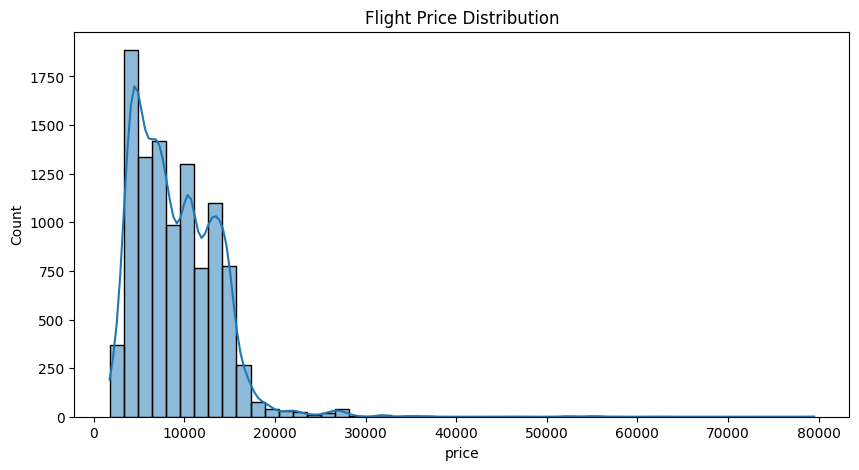

In [14]:
plt.figure(figsize=(10,5))
sns.histplot(df['price'], bins=50, kde=True)
plt.title('Flight Price Distribution')
plt.show()


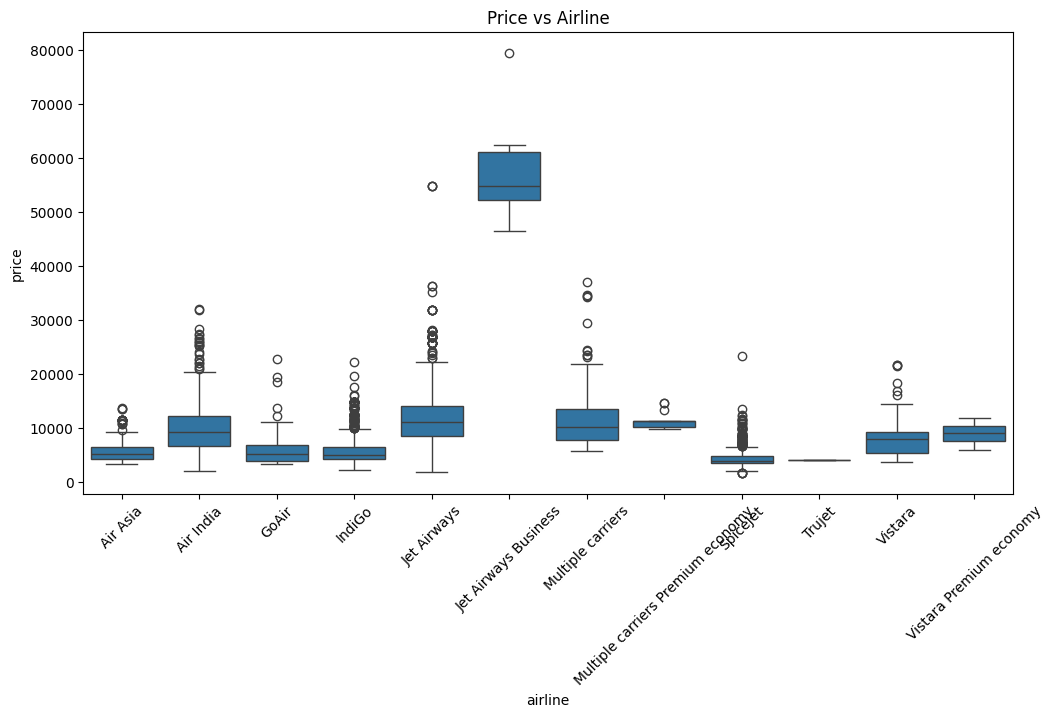

In [15]:
plt.figure(figsize=(12,6))
sns.boxplot(x='airline', y='price', data=df)
plt.xticks(rotation=45)
plt.title('Price vs Airline')
plt.show()

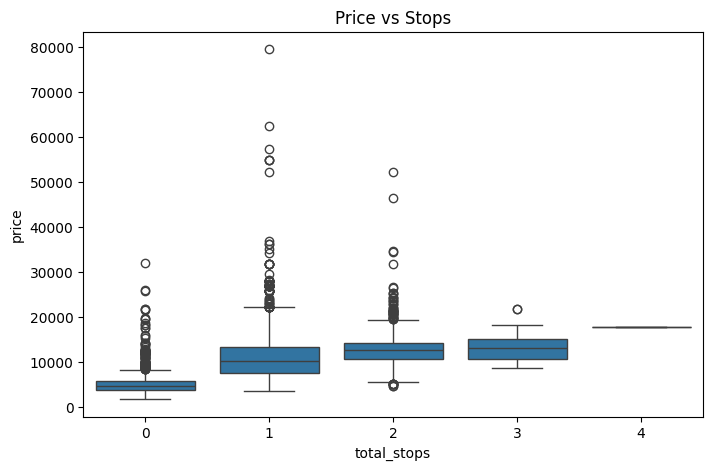

In [16]:
plt.figure(figsize=(8,5))
sns.boxplot(x='total_stops', y='price', data=df)
plt.title('Price vs Stops')
plt.show()

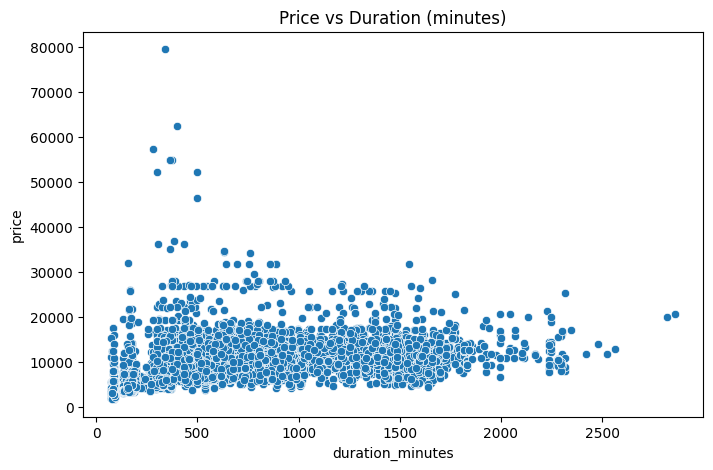

In [17]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='duration_minutes', y='price', data=df)
plt.title('Price vs Duration (minutes)')
plt.show()

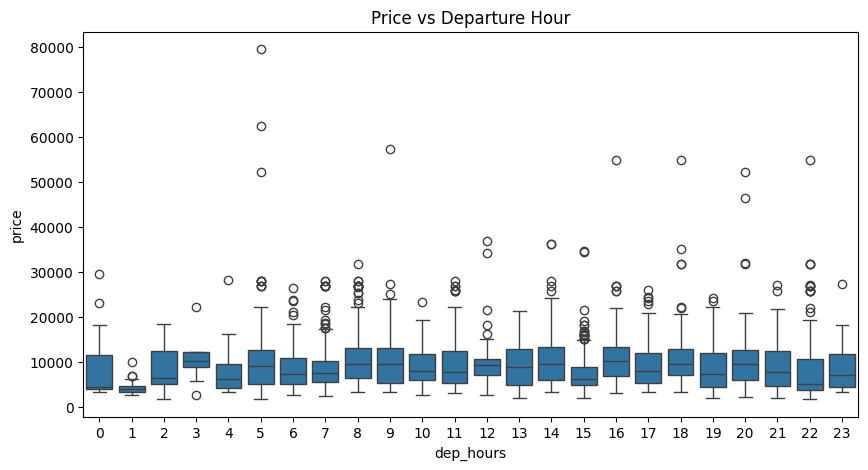

In [18]:
plt.figure(figsize=(10,5))
sns.boxplot(x='dep_hours', y='price', data=df)
plt.title('Price vs Departure Hour')
plt.show()

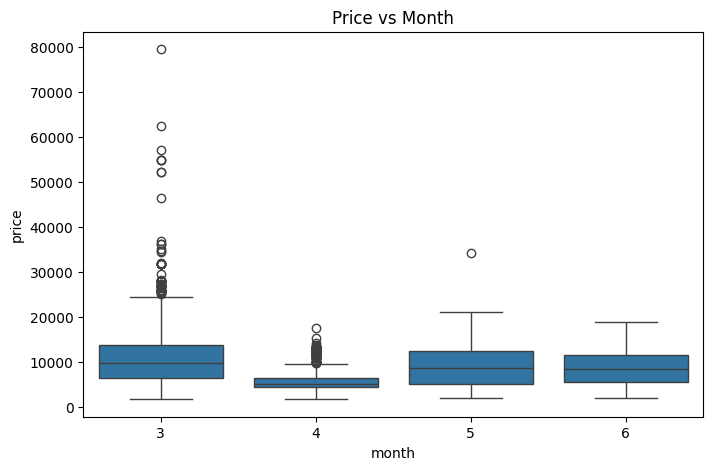

In [19]:
plt.figure(figsize=(8,5))
sns.boxplot(x='month', y='price', data=df)
plt.title('Price vs Month')
plt.show()

In [20]:
# Simplified Revenue Opportunity Score
# Higher score → high price + efficiency (shorter duration)
df['rev_opportunity_score'] = df['price'] / df['duration_minutes']

In [21]:
def segment_routes(row):
    if row['price'] > df['price'].quantile(0.75) and row['duration_minutes'] < df['duration_minutes'].median():
        return 'Premium Route'
    elif row['price'] < df['price'].quantile(0.25) and row['duration_minutes'] > df['duration_minutes'].median():
        return 'Discount Route'
    else:
        return 'Optimization Route'

df['route_segment'] = df.apply(segment_routes, axis=1)


In [22]:
df.groupby('total_stops')['rev_opportunity_score'].mean().sort_values(ascending=False)

total_stops
0    34.445724
1    16.833357
2    13.104050
3    12.007246
4     9.992090
Name: rev_opportunity_score, dtype: float64

<Axes: xlabel='dep_hours'>

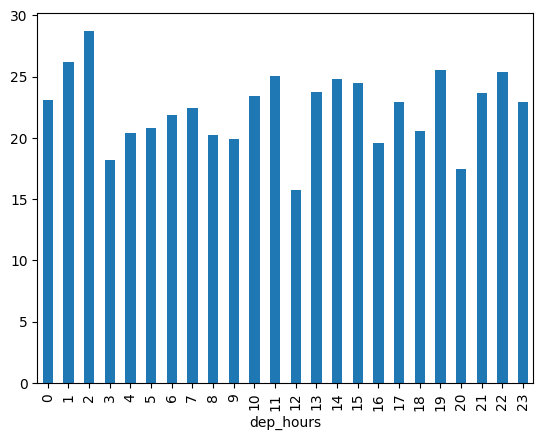

In [23]:
df.groupby('dep_hours')['rev_opportunity_score'].mean().plot(kind='bar')

In [24]:
df.groupby(['airline', 'route_segment'])['rev_opportunity_score'].mean().sort_values(ascending=False)

C:\Users\rihro\AppData\Local\Temp\ipykernel_9864\3682991894.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(['airline', 'route_segment'])['rev_opportunity_score'].mean().sort_values(ascending=False)


airline                            route_segment     
Jet Airways Business               Premium Route         160.981808
GoAir                              Premium Route          80.134032
SpiceJet                           Premium Route          77.432812
Vistara                            Premium Route          75.510845
Air India                          Premium Route          75.385299
IndiGo                             Premium Route          65.918357
Vistara Premium economy            Optimization Route     59.596076
Jet Airways                        Premium Route          43.620412
Air Asia                           Premium Route          40.678520
Multiple carriers                  Premium Route          34.771474
Multiple carriers Premium economy  Premium Route          33.845570
SpiceJet                           Optimization Route     25.569966
IndiGo                             Optimization Route     25.281002
Vistara                            Optimization Route     24.9

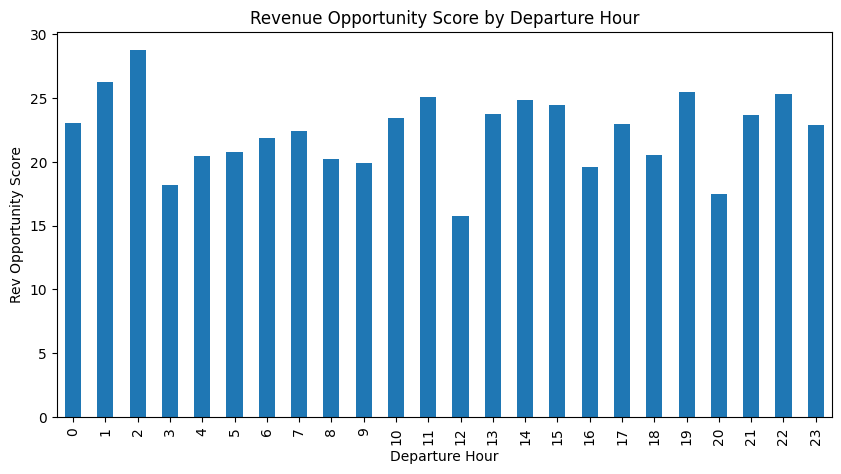

In [25]:
df.groupby('dep_hours')['rev_opportunity_score'].mean().plot(kind='bar', figsize=(10,5))
plt.title('Revenue Opportunity Score by Departure Hour')
plt.xlabel('Departure Hour')
plt.ylabel('Rev Opportunity Score')
plt.show()

In [26]:
# Columns to keep
columns_for_powerbi = [
    'airline',
    'source',
    'destination',
    'total_stops',
    'price',
    'duration_minutes',
    'dep_hours',
    'departure_bucket',
    'month',
    'day_type',
    'route_segment',
    'price_per_hour',
    'rev_opportunity_score'
]

# Create new DataFrame
df_powerbi = df[columns_for_powerbi]

In [27]:
df_powerbi.head()

,airline,source,destination,total_stops,price,duration_minutes,dep_hours,departure_bucket,month,day_type,route_segment,price_per_hour,rev_opportunity_score
0,IndiGo,Banglore,New Delhi,0,3897,170,22,Night,3,Weekend,Optimization Route,1375.411765,22.923529
1,Air India,Kolkata,Banglore,2,7662,445,5,Morning,5,Weekday,Optimization Route,1033.078652,17.217978
2,Jet Airways,Delhi,Cochin,2,13882,1140,9,Morning,6,Weekend,Optimization Route,730.631579,12.177193
3,IndiGo,Kolkata,Banglore,1,6218,325,18,Evening,5,Weekend,Optimization Route,1147.938462,19.132308
4,IndiGo,Banglore,New Delhi,1,13302,285,16,Afternoon,3,Weekday,Premium Route,2800.421053,46.673684


In [28]:
df_powerbi.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10461 entries, 0 to 10682
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype   
---  ------                 --------------  -----   
 0   airline                10461 non-null  category
 1   source                 10461 non-null  category
 2   destination            10461 non-null  category
 3   total_stops            10461 non-null  int64   
 4   price                  10461 non-null  int64   
 5   duration_minutes       10461 non-null  int64   
 6   dep_hours              10461 non-null  int64   
 7   departure_bucket       10461 non-null  category
 8   month                  10461 non-null  int64   
 9   day_type               10461 non-null  category
 10  route_segment          10461 non-null  object  
 11  price_per_hour         10461 non-null  float64 
 12  rev_opportunity_score  10461 non-null  float64 
dtypes: category(5), float64(2), int64(5), object(1)
memory usage: 787.7+ KB


In [29]:
# Export to CSV
df_powerbi.to_csv('flight_pricing_for_powerbi.csv', index=False)

In [30]:
# Create route column
df['route'] = df['source'].astype(str) + " → " + df['destination'].astype(str)

# Select columns for Power BI
df_powerbi = df[['airline','source','destination','route','total_stops','price','duration_minutes',
                 'dep_hours','departure_bucket','month','day_type','route_segment','price_per_hour',
                 'rev_opportunity_score']]

# Export to CSV
df_powerbi.to_csv('flight_pricing_for_powerbi.csv', index=False)
